In [23]:
import pandas as pd
import matplotlib.pyplot as plt


In [24]:
portfolio_df = pd.read_csv("../data/raw/bond_portfolio_data.csv")

print(portfolio_df.shape)
portfolio_df.head()

(300, 44)


,BondID,ISIN,Issuer,Sector,CreditRating,Currency,FaceValue,CouponRate,CouponFrequency,BondType,...,CallDate,IsPutable,IsFloatingRate,BenchmarkIndex,PriceChange_Up50bps,PriceChange_Dn50bps,PriceChange_Up100bps,PriceChange_Dn100bps,PriceChange_Up200bps,PriceChange_Dn200bps
0,ZTFI-0001,IN1043321819,Government of India,Government,SOV,INR,100,0.0620,2,Fixed,...,NaN,False,False,IN10YT,0.9207,-0.9098,1.8522,-1.8086,3.7480,-3.5736
1,ZTFI-0002,IN7940265423,Government of India,Government,SOV,INR,100,0.0773,2,Fixed,...,NaN,False,False,IN10YT,6.1042,-5.6378,12.6747,-10.8091,27.2150,-19.7526
2,ZTFI-0003,IN7816184959,Government of India,Government,SOV,INR,100,0.0555,2,Fixed,...,NaN,False,False,IN10YT,2.0557,-2.0040,4.1631,-3.9562,8.5332,-7.7056
3,ZTFI-0004,IN4752553419,Government of India,Government,SOV,INR,100,0.0681,2,Fixed,...,NaN,False,False,IN10YT,6.3440,-5.7961,13.2358,-11.0444,28.6631,-19.8973
4,ZTFI-0005,IN5030564139,Government of India,Government,SOV,INR,100,0.0750,2,Fixed,...,NaN,False,False,IN10YT,5.4267,-5.0533,11.2267,-9.7333,23.9468,-17.9731


In [25]:
total_market_value = portfolio_df["MarketValue_INR"].sum()

avg_yield = portfolio_df["YieldToMaturity"].mean()

avg_duration = portfolio_df["ModifiedDuration"].mean()

avg_convexity = portfolio_df["Convexity"].mean()

print(f"Total Market Value: ₹{total_market_value:,.2f}")
print(f"Average Yield: {avg_yield:.2%}")
print(f"Average Duration: {avg_duration:.2f}")
print(f"Average Convexity: {avg_convexity:.2f}")

Total Market Value: ₹32,059,345.97
Average Yield: 6.88%
Average Duration: 4.92
Average Convexity: 57.35


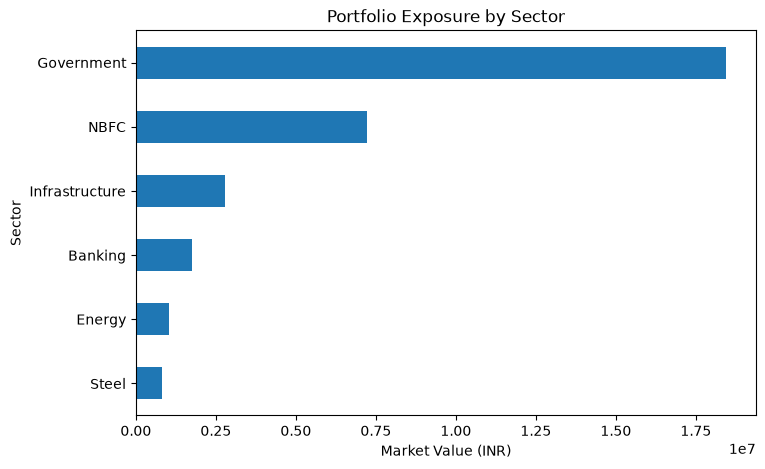

In [26]:
sector_exposure = (
    portfolio_df.groupby("Sector")["MarketValue_INR"]
    .sum()
    .sort_values()
)

sector_exposure.plot(
    kind="barh",
    figsize=(8,5),
    title="Portfolio Exposure by Sector"
)

plt.xlabel("Market Value (INR)")
plt.show()

In [27]:
top_holdings = portfolio_df.nlargest(
    5,
    "MarketValue_INR"
)

top_holdings[
    [
        "BondID",
        "Issuer",
        "Sector",
        "MarketValue_INR"
    ]
]

,BondID,Issuer,Sector,MarketValue_INR
259,ZTFI-0260,UK Gilt,Government,523964.38
91,ZTFI-0092,State of Kerala,Government,519069.50
255,ZTFI-0256,UK Gilt,Government,512137.80
34,ZTFI-0035,Government of India,Government,509404.00
217,ZTFI-0218,Vedanta Ltd,Infrastructure,506124.00


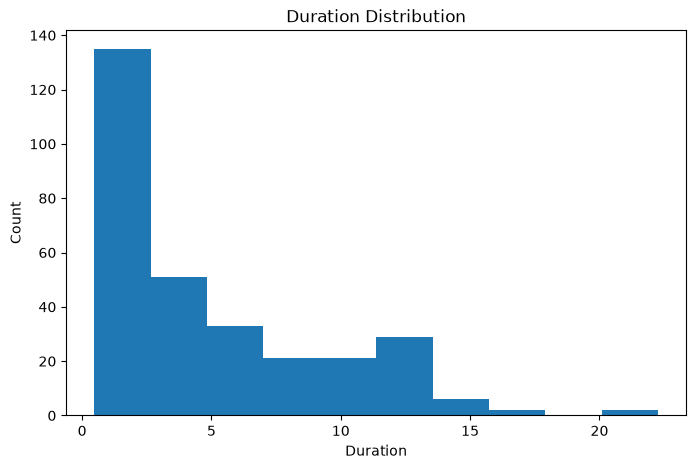

In [28]:
plt.figure(figsize=(8,5))

plt.hist(
    portfolio_df["ModifiedDuration"],
    bins=10
)

plt.title("Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Count")

plt.show()

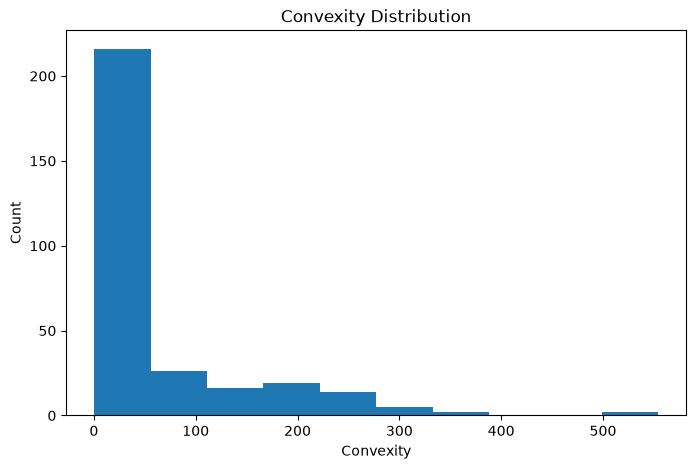

In [29]:
plt.figure(figsize=(8,5))

plt.hist(
    portfolio_df["Convexity"],
    bins=10
)

plt.title("Convexity Distribution")
plt.xlabel("Convexity")
plt.ylabel("Count")

plt.show()

In [30]:
sector_pct = (
    portfolio_df.groupby("Sector")["MarketValue_INR"]
    .sum()
    / total_market_value
    * 100
)

print("Sector Allocation (%)")

sector_pct.sort_values(
    ascending=False
)

Sector Allocation (%)


Sector
Government        57.556094
NBFC              22.484451
Infrastructure     8.688312
Banking            5.517246
Energy             3.199659
Steel              2.554238
Name: MarketValue_INR, dtype: float64

In [31]:
total_market_value = portfolio_df["MarketValue_INR"].sum()

avg_yield = portfolio_df["YieldToMaturity"].mean()

avg_duration = portfolio_df["ModifiedDuration"].mean()

avg_convexity = portfolio_df["Convexity"].mean()

print(f"Total Market Value: ₹{total_market_value:,.2f}")
print(f"Average Yield: {avg_yield:.2f}%")
print(f"Average Duration: {avg_duration:.2f}")
print(f"Average Convexity: {avg_convexity:.2f}")

Total Market Value: ₹32,059,345.97
Average Yield: 0.07%
Average Duration: 4.92
Average Convexity: 57.35
